##### Imports

In [ ]:
import scanpy as sc
import numpy as np
import scipy as sp
import os, sys

##### Climb from the working directory to locate and load the associated source code.

In [ ]:
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR


In [ ]:
from src.markers import cell_cycle_markers, cell_type_markers

In [ ]:
d10_lapa = sc.read_h5ad(DATA_DIR / "data-objects/raw/egfDuod_D10_Lapa_DZ.h5ad")

##### Inspect the AnnData to identify the normalised and raw matrices.

In [ ]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    uns: 'X_name'
    layers: 'counts'

In [ ]:
print(d10_lapa.layers["counts"][:50, :50].toarray())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 2. 0.]
 ...
 [0. 0. 0. ... 0. 3. 0.]
 [0. 0. 0. ... 0. 2. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
print(d10_lapa.X[:50, :50].toarray())

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.42733173 0.        ]
 ...
 [0.         0.         0.         ... 0.         1.0905008  0.        ]
 [0.         0.         0.         ... 0.         1.10660911 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


##### Identify the highly variable genes from the raw data.

In [ ]:
## We're using 'seurat_v3' for a binned approach to variance.

sc.pp.highly_variable_genes(d10_lapa,flavor="seurat", n_top_genes=3000)

In [ ]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg'
    layers: 'counts'

##### Assign and inspect an object with only the highly variable genes, to avoid contamination of the full set representations.

In [ ]:
var = d10_lapa[:, d10_lapa.var['highly_variable']]

In [ ]:
var

View of AnnData object with n_obs × n_vars = 33507 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg'
    layers: 'counts'

##### Scale the variable genes, to account for different expression levels.

In [ ]:
sc.pp.scale(var, max_value=10)
sc.pp.scale(d10_lapa, max_value=10)


/Users/standale/anaconda3/envs/single-cell-backup/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/Users/standale/anaconda3/envs/single-cell-backup/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/standale/anaconda3/envs/single-cell-backup/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
var


AnnData object with n_obs × n_vars = 33507 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    layers: 'counts'

In [ ]:
print(np.min(var.X))
print(np.max(var.X))
print(np.std(var.X))

-3.0731223364942086
10.0
0.6251582249857415


##### Regress out the cell cycle effect, whilst preserving the original data for the trajectory analysis.

In [ ]:
s_genes  = [g for g in cell_cycle_markers["S_genes"]   if g in var.var_names]
s_genes

['RRM2', 'POLA1']

In [ ]:
g2m_genes = [g for g in cell_cycle_markers["G2M_genes"] if g in var.var_names]
g2m_genes

['HMGB2',
 'CDK1',
 'NUSAP1',
 'UBE2C',
 'TPX2',
 'TOP2A',
 'CKS2',
 'MKI67',
 'CENPF',
 'CDC20',
 'DLGAP5',
 'CENPE',
 'GAS2L3']

In [ ]:
sc.tl.score_genes_cell_cycle(var, s_genes=s_genes, g2m_genes=g2m_genes)

#var.obs['S_score'] = d2_dz.obs['S_score']
#var.obs['G2M_score'] = d2_dz.obs['G2M_score']

In [ ]:
sc.pp.regress_out(var, ['S_score', 'G2M_score'])

/Users/standale/anaconda3/envs/single-cell-backup/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/Users/standale/anaconda3/envs/single-cell-backup/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


In [ ]:
## Dimensionality reduction

/Users/standale/anaconda3/envs/single-cell-backup/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


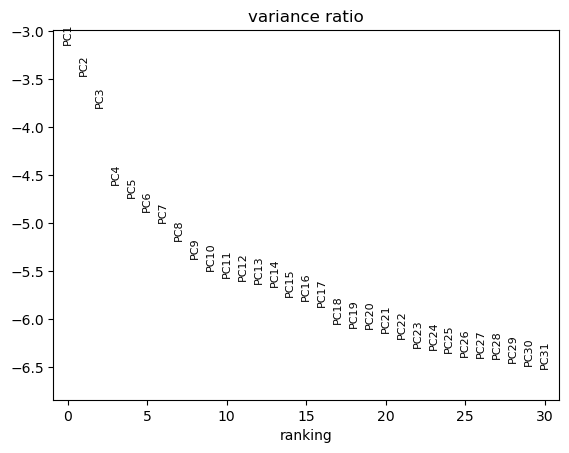

In [ ]:
sc.tl.pca(var, n_comps=50, svd_solver="arpack", use_highly_variable=True)
sc.pl.pca_variance_ratio(var, log=True)

##### Graph construction; using 100NN to preserve the global topology for labelling the distinct lineages. 

In [ ]:
## For more fine-grained subtype labelling, we can subcluster and plot marker genes downstream.

sc.pp.neighbors(var, n_neighbors=100, n_pcs=30, use_rep='X', metric='euclidean')

/Users/standale/anaconda3/envs/single-cell-backup/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
var.obsp.keys()


KeysView(PairwiseArrays with keys: distances, connectivities)

In [ ]:
## Fine-grained clustering

In [ ]:
sc.tl.leiden(var, resolution=3, n_iterations = -1)

/var/folders/rl/j_1783q13wv5fpfxhl3twdm80000gn/T/ipykernel_42200/739609301.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(var, resolution=3, n_iterations = -1)


In [ ]:
var


AnnData object with n_obs × n_vars = 33507 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'pca', 'neighbors', 'leiden'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

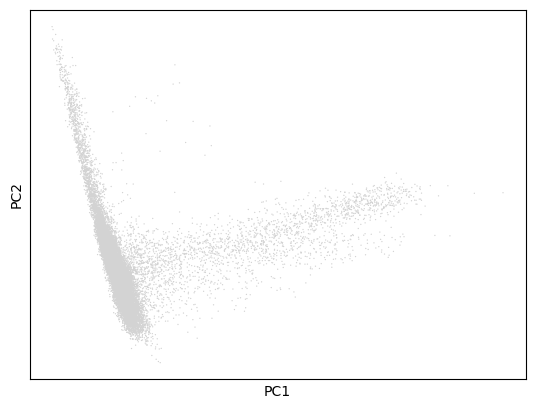

In [33]:
sc.pl.pca(var)

##### let's try an intermediate resolution for this timepoint, from 1 to 0.8


In [ ]:

sc.tl.leiden(var, resolution=1, n_iterations = 2)

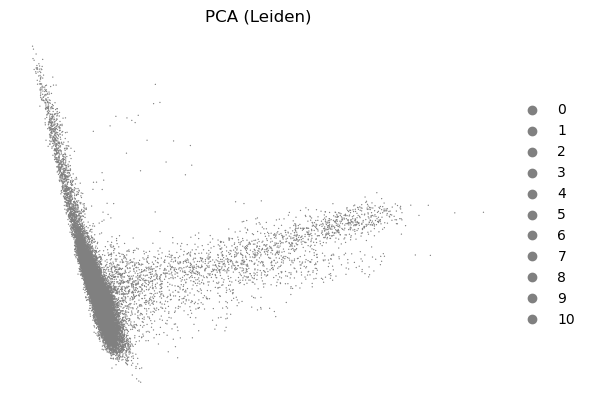

In [37]:
sc.pl.pca(
    var,
    color='leiden',  
    frameon=False,
    title='PCA (Leiden)'
)

##### Ensure the pandas series is type Categorical


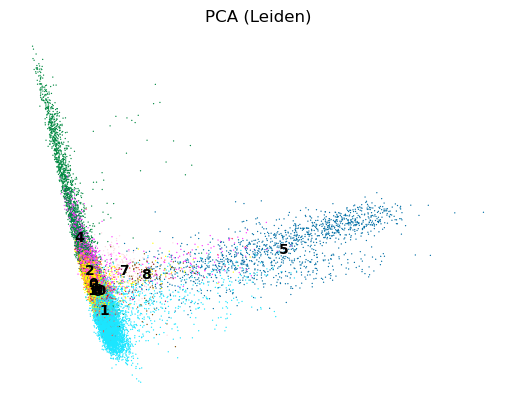

In [ ]:
var.obs['leiden'] = var.obs['leiden'].astype('category')

if 'leiden_colors' in var.uns:
    del var.uns['leiden_colors']

sc.pl.pca(
    var,
    color='leiden',
    palette=sc.pl.palettes.default_102,  
    legend_loc='on data',
    frameon=False,
    title='PCA (Leiden)',
)


##### Compute and plot a UMAP, with the initial clusters.

In [39]:
sc.tl.umap(var)

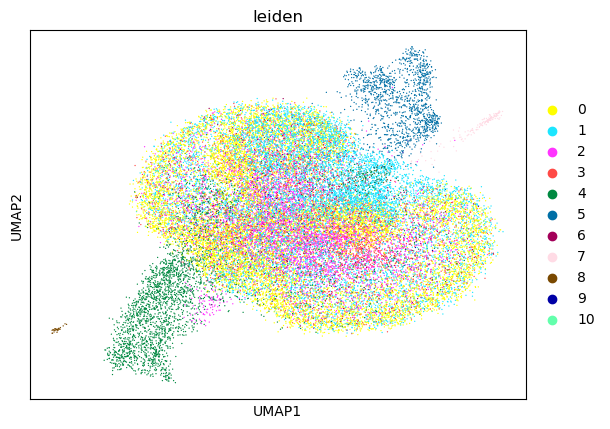

In [ ]:
sc.pl.umap(var, color = 'leiden')

In [41]:
var

AnnData object with n_obs × n_vars = 33507 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'pca', 'neighbors', 'leiden', 'leiden_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

##### Add the embedding coordinates back to the original object

In [ ]:
d10_lapa.obsm['X_pca'] = var.obsm['X_pca']
d10_lapa.obsm['X_umap'] = var.obsm['X_umap']

In [45]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

##### Add back the other metadata for kNN and clustering

In [46]:
d10_lapa.obs['leiden'] = var.obs['leiden'].astype('category')
d10_lapa.obsp['distances'] = var.obsp['distances']
d10_lapa.obsp['connectivities'] = var.obsp['connectivities']

In [47]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

##### Save the result

In [ ]:
intermediate_directory = str(ANALYSIS_DIR / "data-objects/clustered")
sc.write(f'{intermediate_directory}/clustered_egfDuod_D10_Lapa_DZ.h5ad', d10_lapa)